<a href="https://colab.research.google.com/github/rat626/Left-or-Right/blob/main/tda_imu_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import json
import numpy as np
import io
import pandas as pd
from scipy.signal import butter, filtfilt


from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ShirleyRyan/TIBIA.csv', skiprows = 1)
print(df)


#there are expected to be 5391 samples[# of packets]
#Total Duration - (max_sampletimefine - min_sampletimefine)/sampling frequency

#jump between sampletimefine is 8333 - this means that it is likely in microseconds bc 1/8333 microseconds ~ 120Hz - reasonable sampling freq
#Duration = 44923203[maxsampletimefine - minsampletimefine] / 1,000,000[micro -> SI] = 44.923 seconds

#120Hz means that there are 120 samples collected every second
#so 5391/120 = 44.925 seconds where 120 samples are collected every second

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
      PacketCounter  SampleTimeFine    Quat_W    Quat_X    Quat_Y    Quat_Z  \
0                 0      1426938417  0.207182 -0.237096  0.632873 -0.707343   
1                 1      1426946750  0.207171 -0.237091  0.632864 -0.707355   
2                 2      1426955083  0.207179 -0.237100  0.632849 -0.707363   
3                 3      1426963416  0.207173 -0.237108  0.632846 -0.707365   
4                 4      1426971749  0.207175 -0.237115  0.632835 -0.707372   
...             ...             ...       ...       ...       ...       ...   
5387           5387      1471828288  0.573754 -0.707786  0.375881 -0.168996   
5388           5388      1471836621  0.574590 -0.708121  0.371816 -0.173679   
5389           5389      1471844954  0.582629 -0.713316  0.351102 -0.168678   
5390           5390      1471853287  0.591438 -0.720324  0.325147 -0.160042   
53

In [ ]:

#These following blocks were used on a subset - originally took subset of 500 samples[but now extracting all - used in later block]

#CHANGE THIS BLOCK ACCORDING TO THE COLUMNS YOU WANT TO KEEP - THERE ALSO MAY NOT BE SAMPLETIMEFINE
columns_to_keep = ['SampleTimeFine', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z']
df_relevant = df[columns_to_keep].copy()

#Low pass Butterworth filter of 20Hz[2nd order] to Acc axes and Gyr axes

#These are the parameters needed:
sampling_freq = 120.0       # Sampling rate (Hz)
cutoff_freq = 20.0        # Cutoff frequency (Hz)
nyquist_lim = 0.5 * sampling_freq   #nyquist lim - max freq it can record at without noise/disruption

#normalizes the number between 0 and 1; 1 is the nyquist lim
normalized_cutoff = cutoff_freq/nyquist_lim

#a and b are the constants for 2nd order[2 constants]
b, a = butter(N=2, Wn=normalized_cutoff, btype='low', analog=False)

#these are the axes we want to filter - CHANGE THIS BASED ON DATASET
axes_to_filter = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z']

# For loop to implement filtfilt on all axes_to_filter
#In forward direction - it uses each past filtered sample to filter the next with coeffs a and b - causes time lag bc it works on past
#In backward direction, it uses the subsequent/future samples to backfilter the past - gets rid of time delay
for axis in axes_to_filter:
    df_relevant[f'{axis}_Filtered'] = filtfilt(b, a, df_relevant[axis])

# View the original and new filtered columns side-by-side
df_relevant[['Acc_X_Filtered', 'Acc_Y_Filtered', 'Acc_Z_Filtered', 'Gyr_X_Filtered', 'Gyr_Y_Filtered', 'Gyr_Z_Filtered']].head()

#Then combine into acceleration magnitude
df_relevant['Acc_Mag_Filt'] = np.sqrt(df_relevant['Acc_X_Filtered']**2 + df_relevant['Acc_Y_Filtered']**2 + df_relevant['Acc_Z_Filtered']**2)
df_relevant['Gyr_Mag_Filt'] = np.sqrt(df_relevant['Gyr_X_Filtered']**2 + df_relevant['Gyr_Y_Filtered']**2 + df_relevant['Gyr_Z_Filtered']**2)


df_filtered = df_relevant[['SampleTimeFine', 'Acc_Mag_Filt', 'Gyr_Mag_Filt']].copy()
print(df_filtered)


      SampleTimeFine  Acc_Mag_Filt  Gyr_Mag_Filt
0         1426938417      0.000006      0.000027
1         1426946750      6.021005      0.160480
2         1426955083      9.649034      0.229052
3         1426963416     10.692467      0.228906
4         1426971749     10.469682      0.244648
...              ...           ...           ...
5387      1471828288     24.239237    136.313895
5388      1471836621     30.106911    143.490890
5389      1471844954     27.919750    235.487637
5390      1471853287     19.797930    339.615342
5391      1471861620     15.220778    415.234675

[5392 rows x 3 columns]


In [ ]:
#Before embedding, z - score normalize the data - bc right now - one is showing 12.98 one is 102.64 - this is going to ruin relation between variables in h1 space
# (value - mean)/std
df_relevant['Acc_Mag_Scaled'] = (df_relevant['Acc_Mag_Filt'] - df_relevant['Acc_Mag_Filt'].mean()) / df_relevant['Acc_Mag_Filt'].std()
df_relevant['Gyr_Mag_Scaled'] = (df_relevant['Gyr_Mag_Filt'] - df_relevant['Gyr_Mag_Filt'].mean()) / df_relevant['Gyr_Mag_Filt'].std()

print(df_relevant[['Acc_Mag_Scaled', 'Gyr_Mag_Scaled']].head(501))

     Acc_Mag_Scaled  Gyr_Mag_Scaled
0         -3.547360       -1.284458
1         -1.676300       -1.282994
2         -0.548868       -1.282368
3         -0.224615       -1.282369
4         -0.293847       -1.282226
..              ...             ...
496       -0.081854       -0.498731
497       -0.024284       -0.447239
498        0.096563       -0.406821
499        0.264491       -0.375578
500        0.406907       -0.352287

[501 rows x 2 columns]


In [ ]:
#Now - we want to take the Takens delay embeddings of Acc_Mag and Gyr_Mag
#set embedding dimension to 3

!pip install giotto-tda

#Should have a single number for the time delay/dimension across all participants - come up with an estimate
from gtda.time_series import SingleTakensEmbedding

#ADJUST THESE VARIABLES
embedding_dimension = 3 #d=3/4 is usually standard for gait studies
embedding_time_delay = 8 #can do an ami curve and look for the first local minimum/tau at which curve bottoms out

#stride allows you to downsample(eg. if stride was 10 below)
#[f(t), f(t+8), f(t+16)], then [f(t+10), f(t+18), f(t+26)]
#so the windows still overlap, but the samples don't - this may not matter but trying with 1 to start
stride = 1

#bigger stride means less overlap


#WINDOW SIZE = (embedding_dimension - 1)*embedding_time_delay
#so in this case - 2*8 = 16 - meaning that the RANGE of 1 window is 16 samples, but we only take [x0, x8, x16], [x1, x9, x17]...[x_484, x_492, x_500


embedder_periodic = SingleTakensEmbedding(
    parameters_type="fixed",
    n_jobs=2,
    time_delay=embedding_time_delay,
    dimension=embedding_dimension,
    stride=stride, #in the true analysis - stride should be less than the time taken for the # of strides in each window
)


#Run the function on the z - score normalized columns
#acc_point_cloud = embedder_periodic.fit_transform(df_relevant['Acc_Mag_Scaled'])
#gyr_point_cloud = embedder_periodic.fit_transform(df_relevant['Gyr_Mag_Scaled'])


#Now - since we want to see acc/gyr coupling - we combine the point clouds into a 6D space
#PER WINDOW - [Acc_Mag(t), Acc_Mag(t+tau), Acc_Mag(t+2tau), Gyr_Mag(t), Gyr_Mag(t+tau), Gyr_Mag(t+2tau)]

# 2. Glue them together horizontally to make a 6D point cloud
#joint_point_cloud = np.hstack((acc_point_cloud, gyr_point_cloud))

# View the shape to confirm it worked - you need to reduce to 3PCs if you want to see a graph, but can do the persistence diagram per window
#print(f"Joint point cloud shape: {joint_point_cloud.shape}")
# Output will be: (485, 6) w/d = 3 tau = 8 stride = 1


In [ ]:
#Create a persistence diagram per window
#(n_samples, n_points, n_dimensions) - where n_samples is # of point clouds

#Currently the shape of the point cloud is 1 SAMPLE, and 6 dimensions
#the middle dimension will reduce if you increase stride
#So the dimensions will be (1, 485, 6)

#None, :, : - means first is set to 1, and :, : replicates what is already there(485 and 6)
#tda_ready_cloud = joint_point_cloud[None, :, :]


from gtda.homology import VietorisRipsPersistence

# 0 - connected components, 1 - loops, 2 - voids
#UPDATE - since we want the frechet mean of the landscapes SPECIFICALLY FOR H1 - just using 1
homology_dimensions = [1]

periodic_persistence = VietorisRipsPersistence(
    homology_dimensions=homology_dimensions, n_jobs=6
)


Collected point cloud for samples 0 to 500
Collected point cloud for samples 250 to 750
Collected point cloud for samples 500 to 1000
Collected point cloud for samples 750 to 1250
Collected point cloud for samples 1000 to 1500
Collected point cloud for samples 1250 to 1750
Collected point cloud for samples 1500 to 2000
Collected point cloud for samples 1750 to 2250
Collected point cloud for samples 2000 to 2500
Collected point cloud for samples 2250 to 2750
Collected point cloud for samples 2500 to 3000
Collected point cloud for samples 2750 to 3250
Collected point cloud for samples 3000 to 3500
Collected point cloud for samples 3250 to 3750
Collected point cloud for samples 3500 to 4000
Collected point cloud for samples 3750 to 4250
Collected point cloud for samples 4000 to 4500
Collected point cloud for samples 4250 to 4750
Collected point cloud for samples 4500 to 5000
Collected point cloud for samples 4750 to 5250
[[0.         0.         1.11063469 ... 0.         0.         0.     

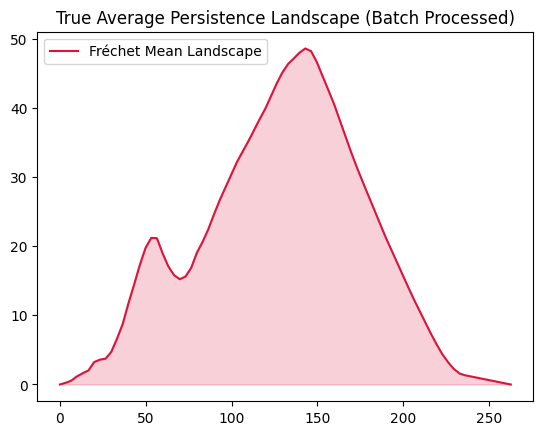

In [ ]:
# THIS BRINGS ALL THE PREVIOUS BLOCKS TOGETHER
import numpy as np
import matplotlib.pyplot as plt
from gtda.diagrams import PersistenceLandscape
from gtda.diagrams import Filtering, PersistenceImage
!pip install antropy
import antropy as ant

#ADJUST THESE VARIABLES

temporal_window_size = 500
temporal_stride = 250
all_clouds = []
sampen_features = []

#This loop combines the joint_point_cloud into a larger 3D array so that giotto-tda accepts it and pads all windows to have same # of features[uses 0,0,0 dummy points]
for start in range(0, len(df_filtered) - temporal_window_size, temporal_stride):
    end = start + temporal_window_size

    se_acc = ant.sample_entropy(df_filtered['Acc_Mag_Filt'].iloc[start:end].values, order=2, metric='chebyshev')
    se_gyr = ant.sample_entropy(df_filtered['Gyr_Mag_Filt'].iloc[start:end].values, order=2, metric='chebyshev')
    sampen_features.append([se_acc, se_gyr])

    acc_cloud = embedder_periodic.fit_transform(df_filtered['Acc_Mag_Filt'].iloc[start:end].values.reshape(-1, 1))
    gyr_cloud = embedder_periodic.fit_transform(df_filtered['Gyr_Mag_Filt'].iloc[start:end].values.reshape(-1, 1))

    joint_cloud = np.hstack((acc_cloud, gyr_cloud))
    all_clouds.append(joint_cloud)

    print(f"Collected point cloud for samples {start} to {end}")

#This stacks the joint_cloud for each window all together - so we have a massive cloud of windows, samples, dimensions
point_clouds_batch = np.stack(all_clouds)

#Use the periodic_persistence object on the entire point cloud to make the persistence diagrams
#This function only performs the padding on a 3D array - cannot do the individual joint clouds for each window
#Array structure is (Windows, Layers, Bins) - so this would be 20, 1, 100)
diagrams_batch = periodic_persistence.fit_transform(point_clouds_batch)


#PIPELINE FOR PERSISTENCE LANDSCAPES
landscape_transformer = PersistenceLandscape(n_layers=1, n_bins=80)
#Turn all of the persistence diagrams into landscapes using the transformer
landscape_batch = landscape_transformer.fit_transform(diagrams_batch)

#Note - this isn't actually a frechet mean, it is the mean persistence landscape - easier to calculate/more standardized value
frechet_mean_landscape = np.mean(landscape_batch, axis=0)

# Use the exact grid the transformer calculated
x_grid = landscape_transformer.samplings_[1]


all_y_vectors = landscape_batch[:, 0, :]
print(all_y_vectors)


#PIPELINE FOR PERSISTENCE HEATMAPS - we transform axes from b, d to b, p
diagrams_bp = diagrams_batch
heatmap_transformer = PersistenceImage(sigma=0.1, n_bins=20)
heatmap_transformer.fit(diagrams_bp) #transformer points are all below line if in b, p form
max_birth = np.max(diagrams_bp[:, :, 0])
max_persistence = np.max(diagrams_bp[:, :, 1] - diagrams_bp[:, :, 0])

#so now we set the limits of the dimensions on the transformer to birth on x axis, persistence on y
heatmap_transformer.homology_dimensions_limits_ = {
    1: [(0.0, max_birth), (0.0, max_persistence)]
}

heatmap_batch = heatmap_transformer.transform(diagrams_bp)
h1_heatmaps = heatmap_batch[:, 0, :, :]


# Note: Depending on your periodic_persistence setup, index [0] usually represents H0
# and index [1] represents H1. If you want H1, you may need frechet_mean_landscape[1].
plt.plot(x_grid, frechet_mean_landscape[0], label="Fréchet Mean Landscape", color="crimson")
plt.fill_between(x_grid, frechet_mean_landscape[0], alpha=0.2, color="crimson")
plt.title("True Average Persistence Landscape (Batch Processed)")
plt.legend()
plt.show()

Plotting Diagram for chunk starting at index 0


Plotting Diagram for chunk starting at index 250


Plotting Diagram for chunk starting at index 500


Plotting Diagram for chunk starting at index 750


Plotting Diagram for chunk starting at index 1000


...

Plotting Diagram for chunk starting at index 4000


Plotting Diagram for chunk starting at index 4250


Plotting Diagram for chunk starting at index 4500


Plotting Diagram for chunk starting at index 4750


Plotting H1 Persistence Image for window 0


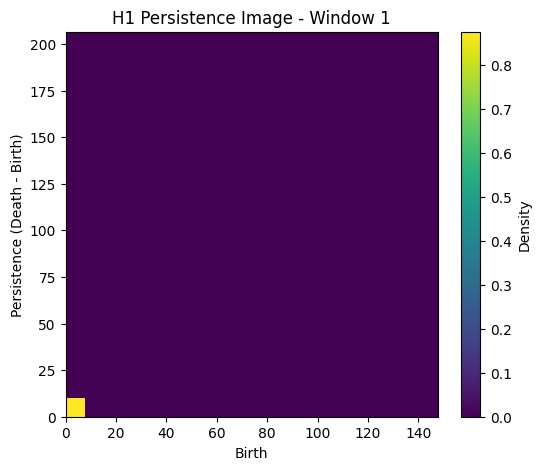

Plotting H1 Persistence Image for window 1


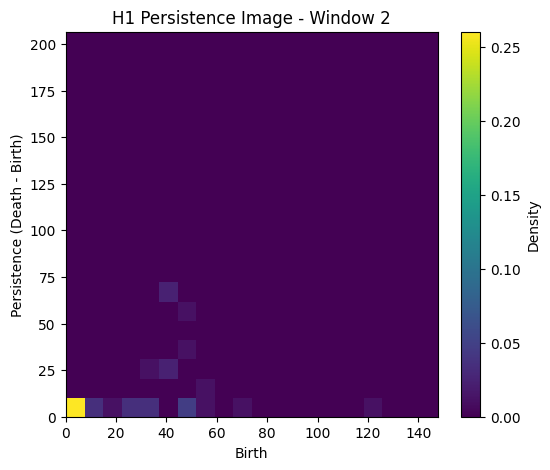

Plotting H1 Persistence Image for window 2


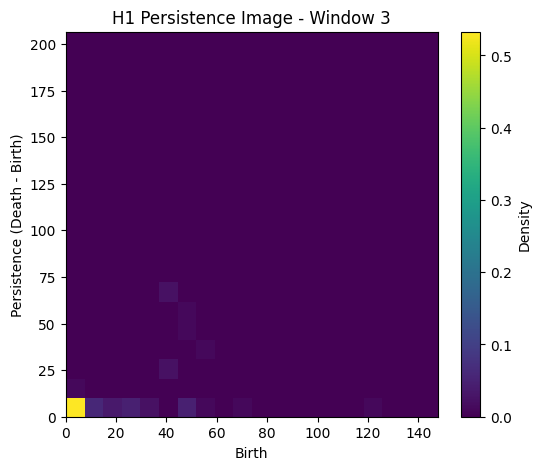

Plotting H1 Persistence Image for window 3


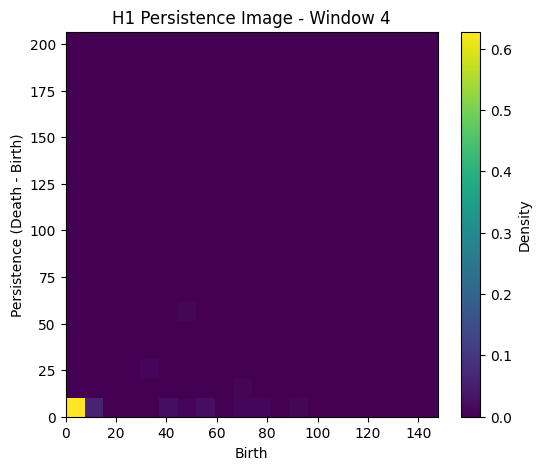

Plotting H1 Persistence Image for window 4


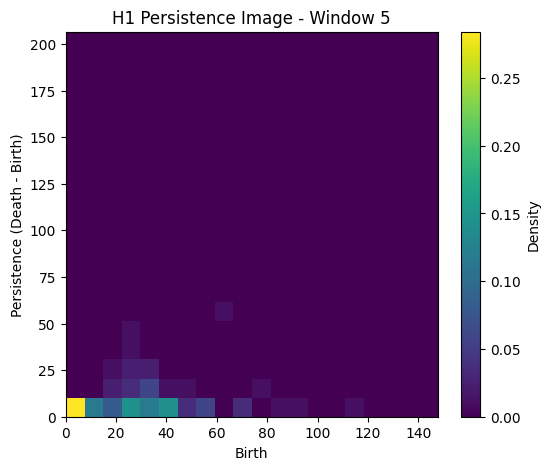

Plotting H1 Persistence Image for window 5


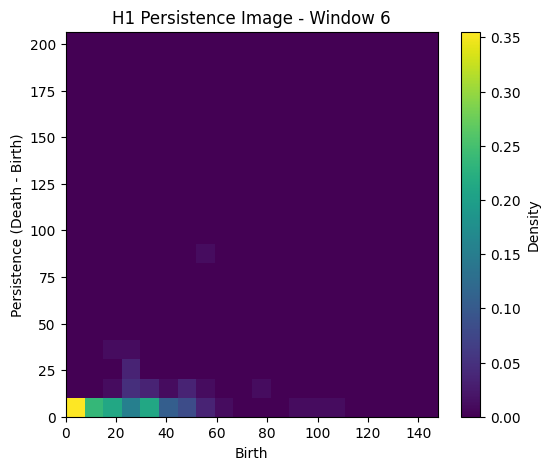

Plotting H1 Persistence Image for window 6


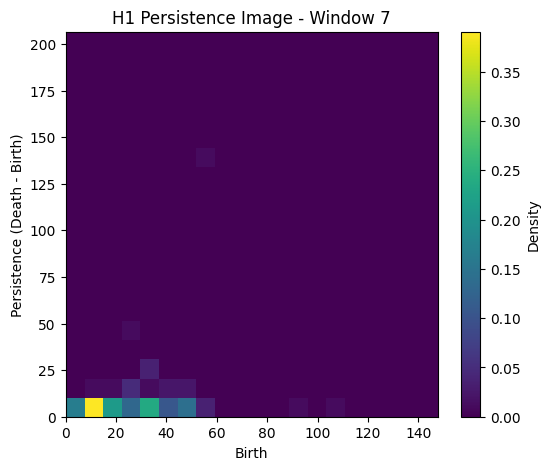

Plotting H1 Persistence Image for window 7


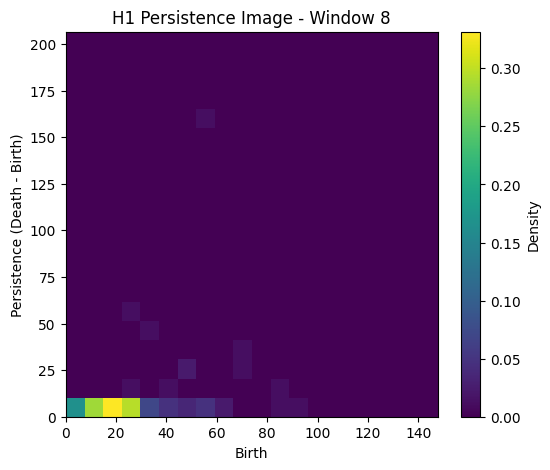

Plotting H1 Persistence Image for window 8


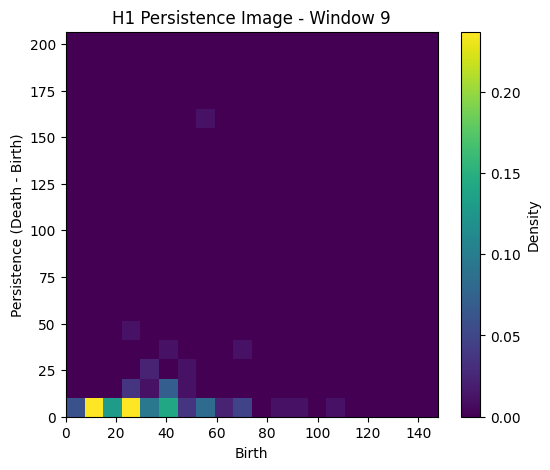

Plotting H1 Persistence Image for window 9


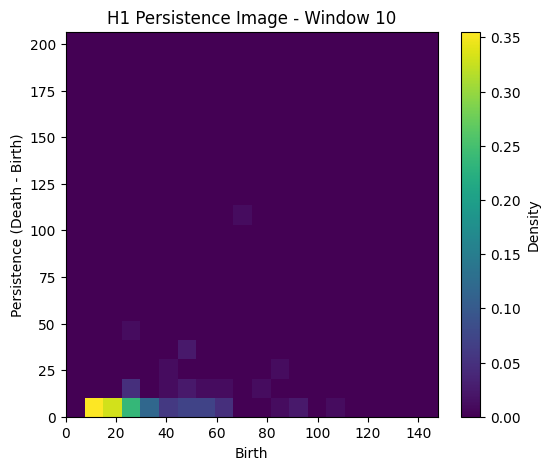

Plotting H1 Persistence Image for window 10


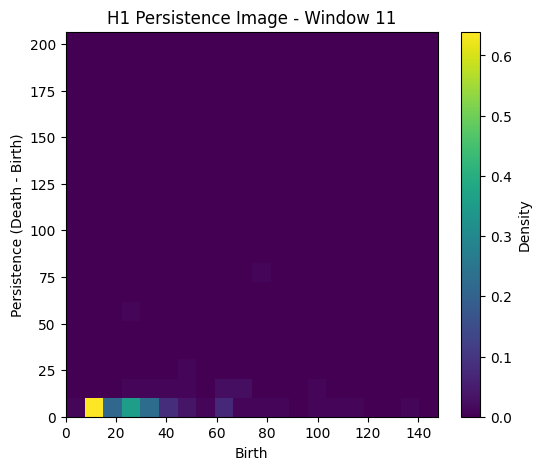

Plotting H1 Persistence Image for window 11


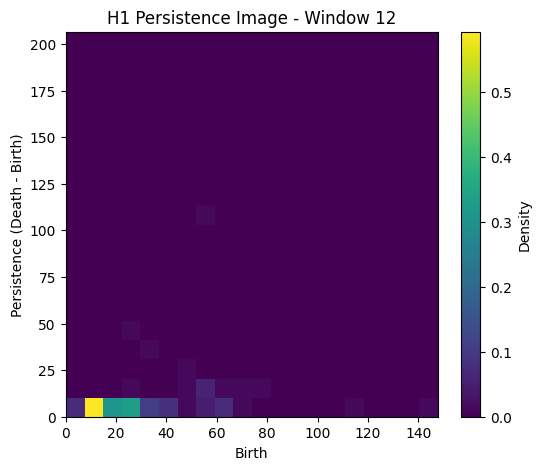

Plotting H1 Persistence Image for window 12


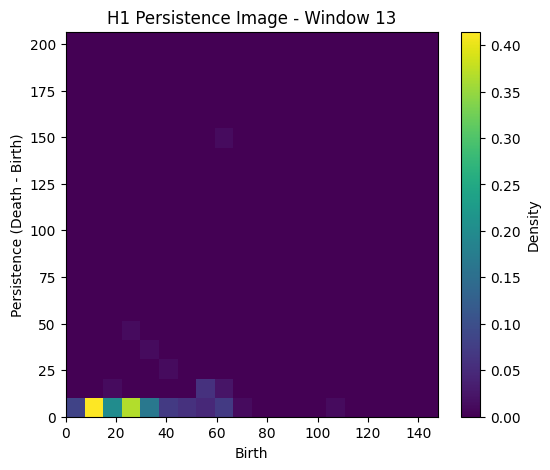

Plotting H1 Persistence Image for window 13


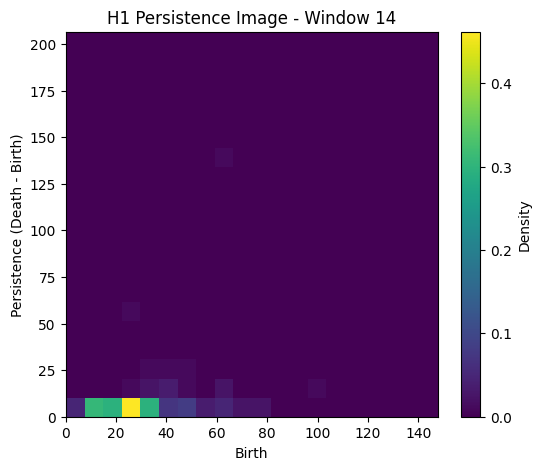

Plotting H1 Persistence Image for window 14


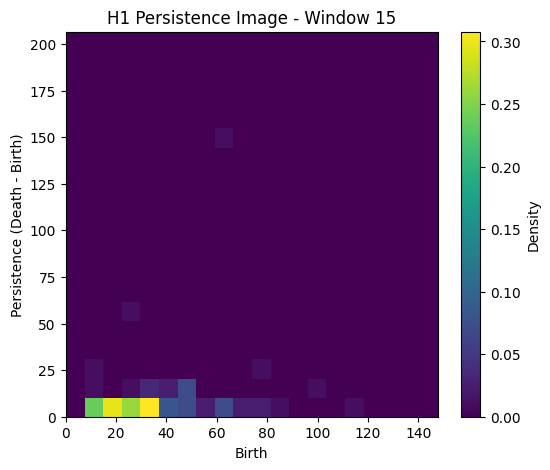

Plotting H1 Persistence Image for window 15


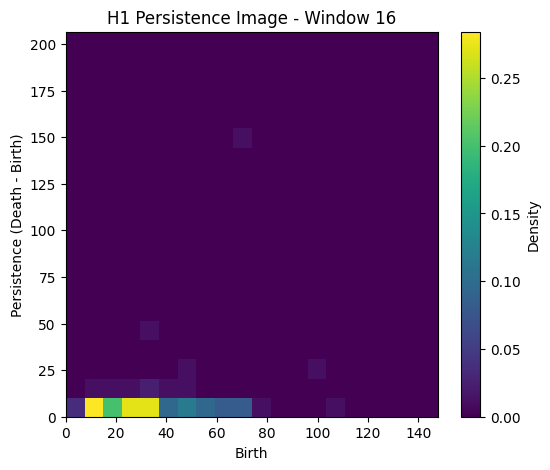

Plotting H1 Persistence Image for window 16


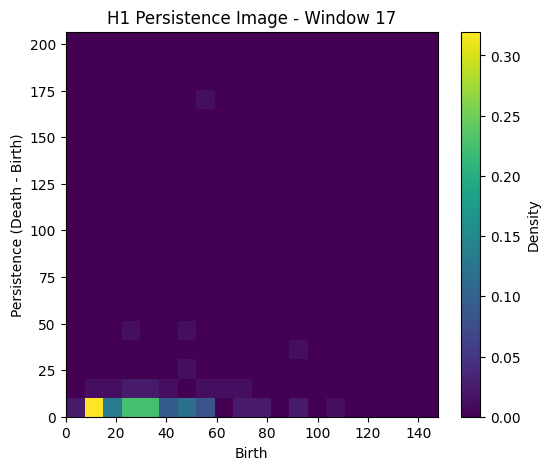

Plotting H1 Persistence Image for window 17


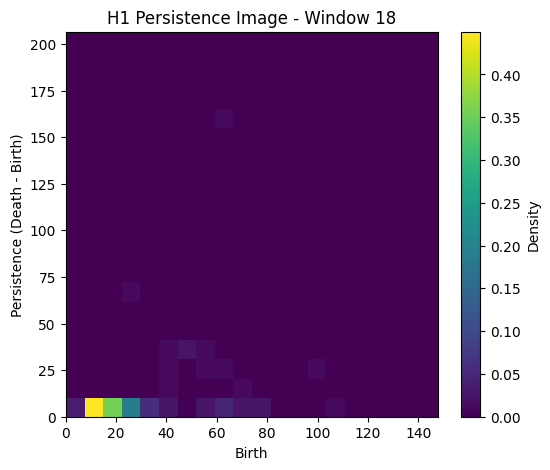

Plotting H1 Persistence Image for window 18


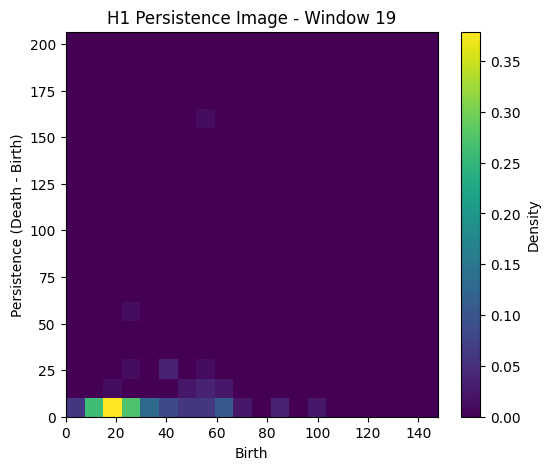

Plotting H1 Persistence Image for window 19


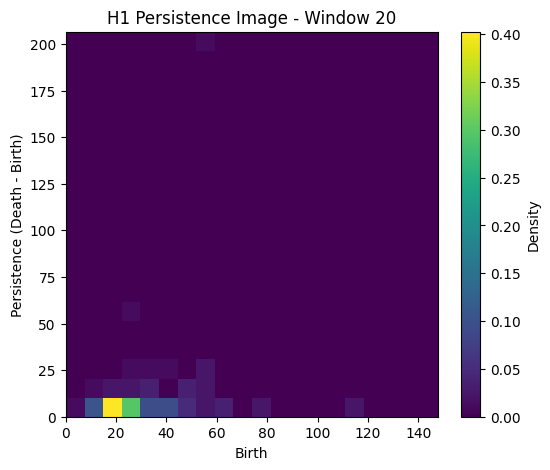

In [ ]:
from gtda.plotting import plot_diagram


# Create a loop to show them in order
for i, diagram in enumerate(diagrams_batch):
    print(f"Plotting Diagram for chunk starting at index {i * 250}")
    fig = plot_diagram(diagrams_batch[i])
    fig.show()


from gtda.plotting import plot_heatmap

import matplotlib.pyplot as plt

# 1. Define your limits (The same ones you used in the transformer)
# Using the values you calculated previously
x_max = max_birth # Your max birth
y_max = max_persistence # Your max persistence

# 2. Iterate and plot
for i in range(len(heatmap_batch)):
    print(f"Plotting H1 Persistence Image for window {i}")

    # Extract the H1 heatmap (index 0 for homology dimension 0)
    # The array shape is (n_windows, n_homology_dims, n_bins, n_bins)
    img = heatmap_batch[i, 0, :, :]


    if np.sum(img) == 0:
        print(f"Warning: Window {i+1} has no persistence features!")
        continue # Skip plotting empty windows to save time


    # Use imshow to plot
    plt.figure(figsize=(6, 5))

    # 'origin=lower' is crucial!
    # Without it, matplotlib starts indexing from the top-left, which
    # flips your persistence plot upside down.
    plt.imshow(np.flipud(img), origin='lower', extent=[0, x_max, 0, y_max],
               cmap='viridis', aspect='auto')

    plt.colorbar(label='Density')
    plt.xlabel("Birth")
    plt.ylabel("Persistence (Death - Birth)")
    plt.title(f"H1 Persistence Image - Window {i+1}")
    plt.show()

In [ ]:
#Now - goal is to make a table of each of the y values for the nodes calculated in each persistence diagram - stack them into one array/csv

#Start with this persistence landscape - because already it is reduced in dimensions - don't want to ruin the resolution of the heatmap

#landscape_batch has all of the landscapes - (n_windows, n_homologydims * n_layers[lambdas], n_bins)

#this way - we only keep n_windows and n_bins
landscape_features = landscape_batch[:, 0, :]
print(landscape_features.shape) #shape is (80, 20) - so 80 is # of bins[rows], 20 is # of windows[cols]

#this is used to make the bin column names for the mean set and the landscapes for all windows
print(x_grid.shape) #shape is (80, ) - so there is only 1 set of x-coordinates used!
col_names = ['Bin_' + str(i) for i in range(1, x_grid.shape[0] + 1)]

#take sampen_features list and put it into a dataframe
entropy_df = pd.DataFrame(
    data=np.array(sampen_features),
    columns=['SampEn_Acc', 'SampEn_Gyr'],
    index=landscape_df.index # This ensures rows match exactly
)
print(entropy_df)


landscape_allwindows_df = pd.DataFrame(
    data = landscape_features,
    index = ['Window' + str(i) for i in range(1, 21)],
    columns = col_names,
)
landscape_allwindows_df = pd.concat([landscape_allwindows_df, entropy_df], axis=1)
print(landscape_allwindows_df)


#make a separate dataframe for the frechet mean
mean_landscape_forml = frechet_mean_landscape[0, :]
print(mean_landscape_forml.shape) #shape is now 80 - before it had the homology dimension included - so flattened to 1D vector

mean_landscape_df = pd.DataFrame(
    data = [mean_landscape_forml], #this forces it to be a horizontal row with 80 indices - not multiple rows since its just an average of all windows
    index = ['Mean_Landscape'],
    columns = col_names
)
#Instead of horizontally concatenating the whole entropy df[which has values for all windows] - we add the mean of SampleAcc and SampleGyr
mean_landscape_df['SampEn_Acc'] = entropy_df['SampEn_Acc'].mean()
mean_landscape_df['SampEn_Gyr'] = entropy_df['SampEn_Gyr'].mean()
print(mean_landscape_df)


(20, 80)
(80,)
          SampEn_Acc  SampEn_Gyr
Window1     0.011465    0.006569
Window2     0.163448    0.060864
Window3     0.138022    0.042221
Window4     0.041618    0.027407
Window5     0.186556    0.208521
Window6     0.338868    0.314289
Window7     0.432639    0.338208
Window8     0.388715    0.310340
Window9     0.404601    0.366161
Window10    0.459328    0.389819
Window11    0.352408    0.332781
Window12    0.370659    0.324444
Window13    0.416343    0.344344
Window14    0.475260    0.346709
Window15    0.535072    0.383181
Window16    0.507754    0.403847
Window17    0.421913    0.391081
Window18    0.412855    0.348455
Window19    0.444133    0.361557
Window20    0.510221    0.427329
          Bin_1     Bin_2     Bin_3     Bin_4     Bin_5     Bin_6     Bin_7  \
Window1     0.0  0.000000  1.110635  0.582729  0.000000  0.000000  0.000000   
Window2     0.0  0.000000  2.633696  1.326455  0.000000  0.000000  0.000000   
Window3     0.0  2.282895  2.570094  5.893403  4.640792

In [ ]:
#Final step is to use Standard Scaler to standardize the differences in magnitude between the lambda1 values in each window/mean and SampEn of acc and gyr

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(landscape_allwindows_df)

allandscapes_final_df = pd.DataFrame(
    scaled_matrix,
    columns=landscape_allwindows_df.columns,
    index=landscape_allwindows_df.index
)


scaled_data_mean = scaler.fit_transform(mean_landscape_df)

meanlandscape_final_df = pd.DataFrame(
    scaled_data_mean,
    columns=mean_landscape_df.columns,
    index=mean_landscape_df.index
)


# 1. Export the primary ML matrix (20 windows x 80 features)
allandscapes_final_df.to_csv('gait_landscape_ml_features.csv', index_label='Window_ID')

# 2. Export the average landscape row
meanlandscape_final_df.to_csv('mean_gait_landscape.csv', index_label='Metric_Type')

